## 1. Load data from Supabase

In [53]:
from sqlalchemy import create_engine
import pandas as pd
import os
from dotenv import load_dotenv

load_dotenv()

host = os.getenv("SUPABASE_HOST")
user = os.getenv("SUPABASE_USER")
password = os.getenv("SUPABASE_PASSWORD")

engine = create_engine(f"postgresql+psycopg2://{user}:{password}@{host}:6543/postgres")

query = """
    SELECT
        a.activity_name, a.start_date, a.activity_type,
        a.distance, a.duration, a.elevation,
        a.max_speed, a.avg_speed, a.avg_heartrate,
        a.suffer_score, a.avg_watts, a.kilojoules,
        a.start_lat, a.start_lng, a.end_lat, a.end_lng
    FROM activities a
    JOIN athletes ath ON a.athlete_id = ath.id
    ORDER BY a.start_date DESC
"""

df = pd.read_sql(query, engine)
df["start_date"] = pd.to_datetime(df["start_date"])

splits_query = """
    SELECT
        s.id AS split_id,
        s.activity_id,
        s.split_number,
        s.distance_km,
        s.elapsed_time_s,
        s.moving_time_s,
        s.elevation_diff_m,
        s.avg_speed_kmh,
        s.avg_heartrate,
        s.pace_zone,
        a.activity_name,
        a.start_date,
        a.activity_type
    FROM splits s
    JOIN activities a ON s.activity_id = a.id
    ORDER BY a.start_date DESC, s.split_number ASC
"""

df_splits = pd.read_sql(splits_query, engine)
df_splits["start_date"] = pd.to_datetime(df_splits["start_date"])

In [ ]:
## Check df variables for Strava

import json
print(df)

In [1]:
## Check df variables for FitNotes

import pandas as pd

df_fitnotes = pd.read_csv(r"C:\Users\persif\PycharmProjects\SportAnalytics\FitNotes_Export.csv")
print(df_fitnotes.info())
print(df_fitnotes.head())

<class 'pandas.DataFrame'>
RangeIndex: 9016 entries, 0 to 9015
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9016 non-null   str    
 1   Exercise       9016 non-null   str    
 2   Category       9016 non-null   str    
 3   Weight         8257 non-null   float64
 4   Weight Unit    8257 non-null   str    
 5   Reps           8252 non-null   float64
 6   Distance       621 non-null    float64
 7   Distance Unit  621 non-null    str    
 8   Time           753 non-null    str    
dtypes: float64(3), str(6)
memory usage: 634.1 KB
None
         Date             Exercise Category  Weight Weight Unit  Reps  \
0  2021-04-16              Cycling   Cardio     NaN         NaN   NaN   
1  2021-04-16              Cycling   Cardio     NaN         NaN   NaN   
2  2021-04-16  EZ-Bar Skullcrusher  Triceps    15.0         kgs  10.0   
3  2021-04-16  EZ-Bar Skullcrusher  Triceps    15.0         kgs  10.0   
4

## 2. Visualize activity results
Plot various metrics from the Strava activities, such as distance, duration, elevation gain, and average speed over time.

Taken from the exported .csv of GymNotes, though functionality exists for Strava, incomplete running data made the graph look moh.

## 2.1 All Distance Run over Time
Every outdoor run plotted chronologically from the first recorded session to the most recent. A trend line captures the long-term direction of average run distance, with an annotation showing the monthly rate of change and the total distance gained across the full period.

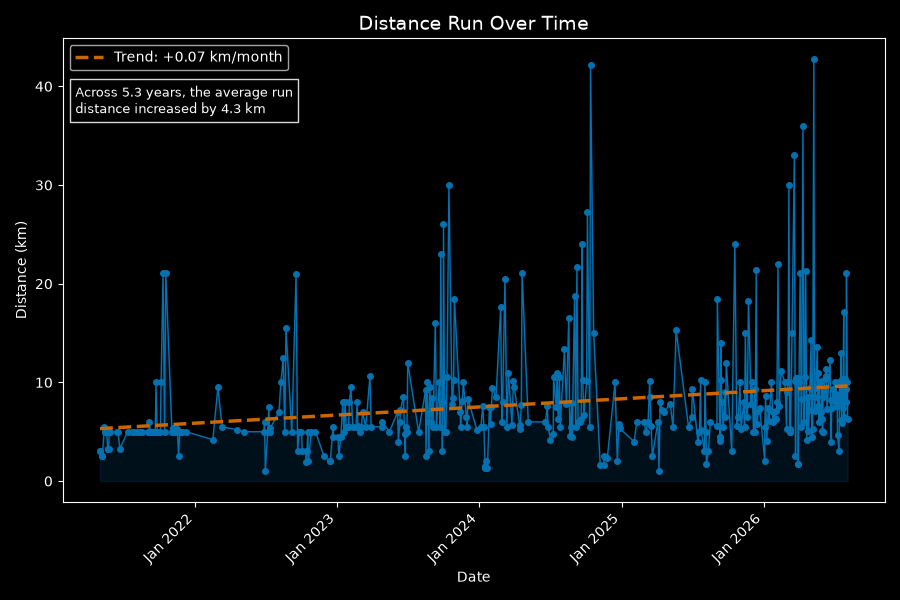

In [51]:
%matplotlib widget
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import mplcursors

FIGURES_DIR = r"C:\Users\persif\PycharmProjects\SportAnalytics\figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

SKY_BLUE = "#0571B0"
SLATE    = "#CA6702"

df_fitnotes = pd.read_csv(r"C:\Users\persif\PycharmProjects\SportAnalytics\FitNotes_Export.csv")
df_fitnotes["Date"] = pd.to_datetime(df_fitnotes["Date"])

runs = (df_fitnotes[df_fitnotes["Exercise"] == "Running (Outdoor)"]
        .dropna(subset=["Distance"])
        .sort_values("Date"))

days = (runs["Date"] - runs["Date"].iloc[0]).dt.days.values
z = np.polyfit(days, runs["Distance"].values, 1)
p = np.poly1d(z)
slope_per_month = z[0] * 30.44

total_days = (runs["Date"].iloc[-1] - runs["Date"].iloc[0]).days
total_increase = z[0] * total_days
years = total_days / 365.25

fig, ax = plt.subplots(figsize=(9, 6))
line, = ax.plot(runs["Date"], runs["Distance"], marker="o", linewidth=1, markersize=4, color=SKY_BLUE, zorder=3)
ax.fill_between(runs["Date"], runs["Distance"], alpha=0.15, color=SKY_BLUE)
ax.plot(runs["Date"], p(days), "--", color=SLATE, linewidth=2.5, zorder=5,
        label=f"Trend: {slope_per_month:+.2f} km/month")

legend = ax.legend(loc="upper left", fontsize=10)

ax.set_title("Distance Run Over Time", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Distance (km)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# Measure the legend bottom in axes coords and place note directly below
fig.canvas.draw()
bbox = legend.get_window_extent()
inv = ax.transAxes.inverted()
x0_ax, y0_ax = inv.transform([bbox.x0, bbox.y0])

note = (f"Across {years:.1f} years, the average run\n"
        f"distance increased by {total_increase:.1f} km")
ax.text(x0_ax + 0.007, y0_ax - 0.03, note, transform=ax.transAxes,
        fontsize=9, va="top", ha="left", color="white",
        bbox=dict(boxstyle="square,pad=0.4", facecolor="black", edgecolor="white", alpha=0.85))

fig.savefig(os.path.join(FIGURES_DIR, "2-1_distance_over_time.png"), dpi=150)
plt.show()

cursor = mplcursors.cursor(line, hover=False)
prev_sel = [None]

@cursor.connect("add")
def on_add(sel, p=prev_sel):
    if p[0] is not None:
        p[0].annotation.set_visible(False)
        fig.canvas.draw_idle()
    p[0] = sel
    row = runs.iloc[sel.index]
    sel.annotation.set_text(
        f"{row['Date'].strftime('%d %b %Y')}\n"
        f"Distance: {row['Distance']:.1f} km"
    )

## 2.2 Yearly Total Running Distance
Total distance accumulated per calendar year, showing how running volume has grown year-on-year. The summary panel reports lifetime totals across all recorded runs — number of sessions, cumulative distance, and total time on feet.

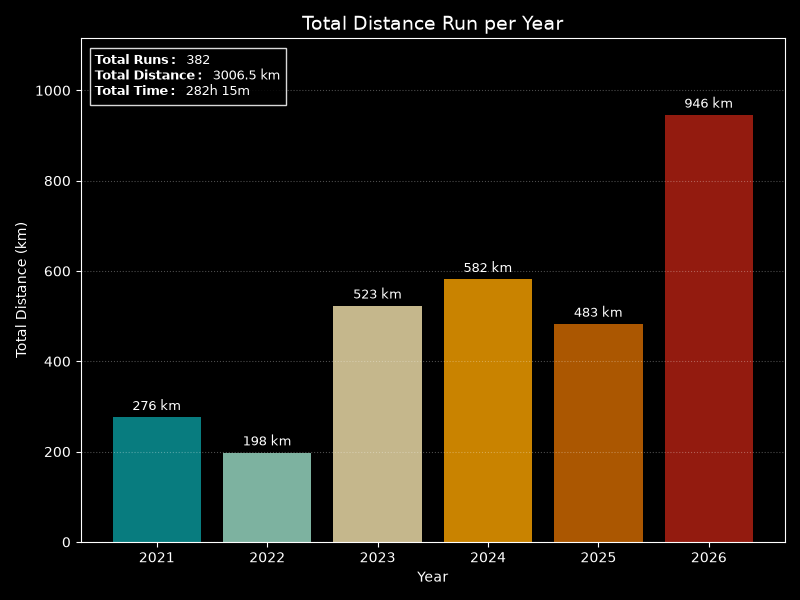

In [30]:
%matplotlib widget
import os
import pandas as pd
import matplotlib.pyplot as plt

FIGURES_DIR = r"C:\Users\persif\PycharmProjects\SportAnalytics\figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

HEATMAP0 = ["#0A9396", "#94D2BD", "#E9D8A6", "#EE9B00", "#CA6702", "#AE2012", "#9B2226"]

df_fitnotes = pd.read_csv(r"C:\Users\persif\PycharmProjects\SportAnalytics\FitNotes_Export.csv")
df_fitnotes["Date"] = pd.to_datetime(df_fitnotes["Date"])

runs = (df_fitnotes[df_fitnotes["Exercise"] == "Running (Outdoor)"]
        .dropna(subset=["Distance"])
        .copy())

def parse_time_to_minutes(t):
    if pd.isna(t) or str(t).strip() == "":
        return 0
    parts = str(t).strip().split(":")
    if len(parts) == 3:
        return int(parts[0]) * 60 + int(parts[1]) + int(parts[2]) / 60
    elif len(parts) == 2:
        return int(parts[0]) + int(parts[1]) / 60
    return 0

runs["minutes"] = runs["Time"].apply(parse_time_to_minutes)
runs["year"] = runs["Date"].dt.year

yearly = runs.groupby("year")["Distance"].sum().reset_index()

total_dist = runs["Distance"].sum()
total_mins = runs["minutes"].sum()
total_hrs = int(total_mins // 60)
total_min_rem = int(total_mins % 60)
total_runs = len(runs)

colors = HEATMAP0[:len(yearly)]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(yearly["year"].astype(str), yearly["Distance"], color=colors, alpha=0.85)
ax.set_title("Total Distance Run per Year", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Total Distance (km)")
ax.set_ylim(0, yearly["Distance"].max() * 1.18)
ax.grid(axis="y", alpha=0.3, linestyle=":")

for bar, val in zip(bars, yearly["Distance"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + yearly["Distance"].max() * 0.01,
        f"{val:.0f} km",
        ha="center", va="bottom", fontsize=9, color="white", clip_on=False,
    )

summary = (
    r"$\bf{Total\ Runs:}$" + f"  {total_runs}\n"
    r"$\bf{Total\ Distance:}$" + f"  {total_dist:.1f} km\n"
    r"$\bf{Total\ Time:}$" + f"  {total_hrs}h {total_min_rem}m"
)
ax.text(0.02, 0.97, summary, transform=ax.transAxes,
        fontsize=9, va="top", ha="left", color="white",
        bbox=dict(boxstyle="square,pad=0.4", facecolor="black", edgecolor="white", alpha=0.85))

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "2-2_yearly_running_summary.png"), dpi=150)
plt.show()

## 2.3 Side-by-side comparison of individual run distances across two marathon training blocks.
Each dot is one run; the fill shows the volume envelope over time. 7-day rolling avg: mean distance of the last 7 runs (not calendar days), smoothing out the natural spike-and-dip between hard long runs and short recovery runs to reveal whether the training load is building, holding, or tapering.

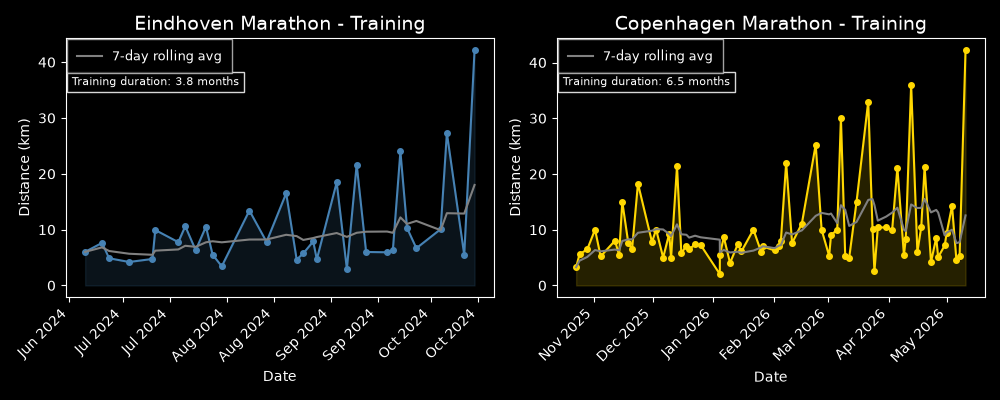

In [64]:
%matplotlib widget
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import mplcursors
import pandas as pd

FIGURES_DIR = r"C:\Users\persif\PycharmProjects\SportAnalytics\figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

runs = (df[df["activity_type"] == "Run"]
        .dropna(subset=["distance"])
        .sort_values("start_date"))

def max_per_day(data):
    return data.loc[data.groupby(data["start_date"].dt.date)["distance"].idxmax()]

marathon1 = max_per_day(runs[(runs["start_date"] >= "2024-06-01") & (runs["start_date"] < "2024-10-14")])
marathon2 = runs[(runs["start_date"] >= "2025-10-20") & (runs["start_date"] < "2026-05-11")]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

cursors = []
legends = []
axes_meta = []

for ax, data, title, color in [
    (ax1, marathon1, "Eindhoven Marathon - Training", "steelblue"),
    (ax2, marathon2, "Copenhagen Marathon - Training", "gold"),
]:
    line, = ax.plot(data["start_date"], data["distance"], marker="o", linewidth=1.5, markersize=4, color=color)
    ax.fill_between(data["start_date"], data["distance"], alpha=0.15, color=color)

    rolling_avg = data["distance"].rolling(7, min_periods=1).mean()
    ax.plot(data["start_date"], rolling_avg, "-", color="grey", linewidth=1.5, zorder=5,
            label="7-day rolling avg")
    legend = ax.legend(loc="upper left", fontsize=9)
    legend.get_frame().set_boxstyle("square,pad=0.4")
    legends.append(legend)

    training_months = (data["start_date"].iloc[-1] - data["start_date"].iloc[0]).days / 30.44
    axes_meta.append((ax, training_months))

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Date")
    ax.set_ylabel("Distance (km)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    cursor = mplcursors.cursor(line, hover=False)
    cursors.append(cursor)
    prev_sel = [None]

    @cursor.connect("add")
    def on_add(sel, d=data, p=prev_sel):
        if p[0] is not None:
            p[0].annotation.set_visible(False)
            fig.canvas.draw_idle()
        p[0] = sel
        row = d.iloc[sel.index]
        sel.annotation.set_text(
            f"{row['start_date'].strftime('%d %b %Y')}\n"
            f"Distance: {row['distance']:.1f} km\n"
            f"Suffer Score: {row.get('suffer_score', 'N/A')}"
        )

plt.tight_layout()
fig.canvas.draw()

for (ax, training_months), legend in zip(axes_meta, legends):
    bbox = legend.get_window_extent()
    inv = ax.transAxes.inverted()
    x0_ax, y0_ax = inv.transform([bbox.x0, bbox.y0])
    ax.text(x0_ax, y0_ax - 0.03,
            f"Training duration: {training_months:.1f} months",
            transform=ax.transAxes,
            fontsize=8, va="top", ha="left", color="white",
            bbox=dict(boxstyle="square,pad=0.4", facecolor="black", edgecolor="white", alpha=0.85))

fig.savefig(os.path.join(FIGURES_DIR, "2-3_marathon_training_comparison.png"), dpi=150)
plt.show()

## 2.4 Marathon Training Trajectory Comparison
Weekly peak run distance and monthly total volume plotted on a shared training timeline, allowing direct comparison of how each marathon build-up progressed from month one to race day.

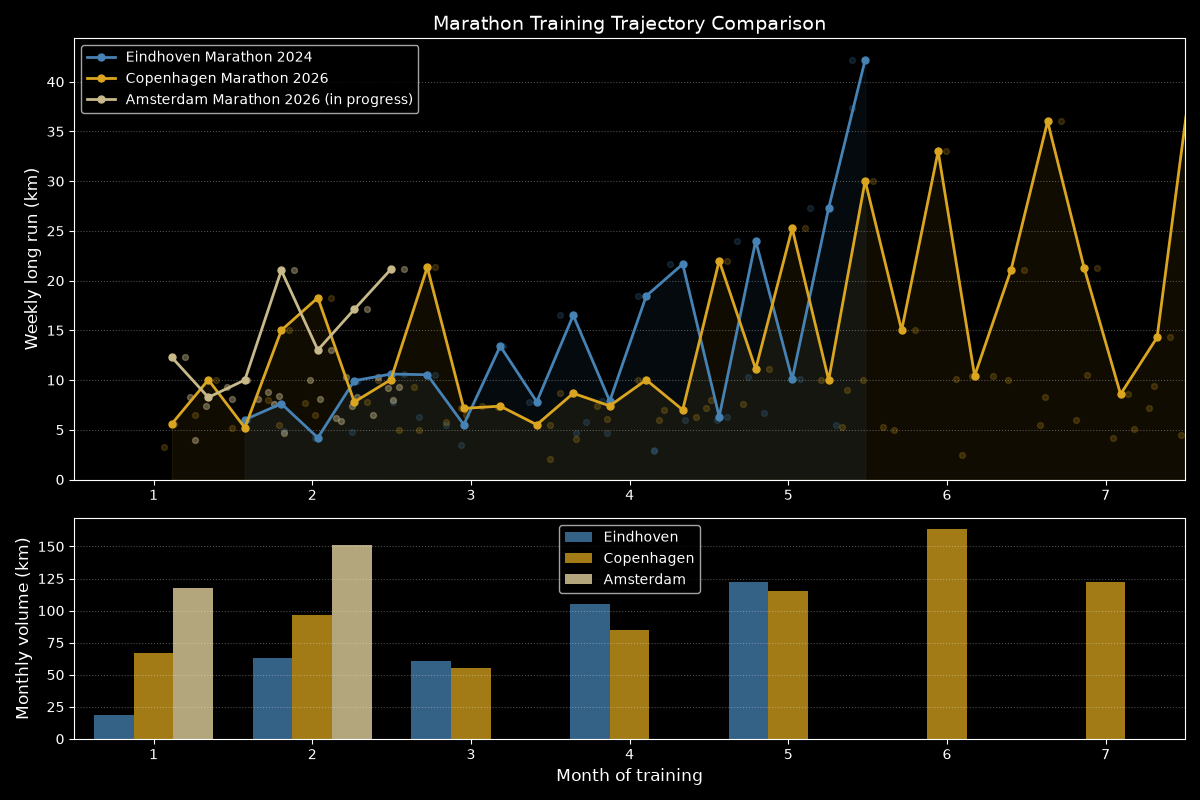

In [56]:
%matplotlib widget
import os
import matplotlib.pyplot as plt
import pandas as pd

FIGURES_DIR = r"C:\Users\persif\PycharmProjects\SportAnalytics\figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

runs = (df[df["activity_type"] == "Run"]
        .dropna(subset=["distance"])
        .sort_values("start_date"))

# Training windows
start1 = pd.Timestamp("2024-06-01")
start2 = pd.Timestamp("2025-10-20")
start3 = pd.Timestamp("2026-06-15")

m1 = runs[(runs["start_date"] >= start1) & (runs["start_date"] < "2024-10-14")].copy()
m2 = runs[(runs["start_date"] >= start2) & (runs["start_date"] < "2026-05-11")].copy()
m3 = runs[runs["start_date"] >= start3].copy()

def weekly_long_run(data, start):
    d = data.copy()
    d["week"] = (d["start_date"] - start).dt.days // 7
    wk = d.groupby("week")["distance"].max().reset_index()
    wk["month"] = (wk["week"] * 7 + 3.5) / 30.44 + 1
    return wk

def monthly_volume(data, start):
    d = data.copy()
    d["month_bin"] = (d["start_date"] - start).dt.days // 30 + 1
    return d.groupby("month_bin")["distance"].sum().reset_index().rename(
        columns={"month_bin": "month", "distance": "total_dist"})

wlr1 = weekly_long_run(m1, start1)
wlr2 = weekly_long_run(m2, start2)
wlr3 = weekly_long_run(m3, start3)
vol1  = monthly_volume(m1, start1)
vol2  = monthly_volume(m2, start2)
vol3  = monthly_volume(m3, start3)

CREAM = "#C8B98A"

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(12, 8),
    gridspec_kw={"height_ratios": [2, 1]}
)

# --- Top: individual runs (faded) + weekly long run line ---
ax_top.scatter(
    (m1["start_date"] - start1).dt.days / 30.44 + 1, m1["distance"],
    alpha=0.2, color="steelblue", s=18, zorder=2
)
ax_top.scatter(
    (m2["start_date"] - start2).dt.days / 30.44 + 1, m2["distance"],
    alpha=0.2, color="goldenrod", s=18, zorder=2
)
ax_top.scatter(
    (m3["start_date"] - start3).dt.days / 30.44 + 1, m3["distance"],
    alpha=0.4, color=CREAM, s=18, zorder=2
)

ax_top.plot(wlr1["month"], wlr1["distance"], color="steelblue", linewidth=2, marker="o", markersize=5, label="Eindhoven Marathon 2024")
ax_top.plot(wlr2["month"], wlr2["distance"], color="goldenrod",  linewidth=2, marker="o", markersize=5, label="Copenhagen Marathon 2026")
ax_top.plot(wlr3["month"], wlr3["distance"], color=CREAM,        linewidth=2, marker="o", markersize=5, label="Amsterdam Marathon 2026 (in progress)")
ax_top.fill_between(wlr1["month"], 0, wlr1["distance"], alpha=0.08, color="steelblue")
ax_top.fill_between(wlr2["month"], 0, wlr2["distance"], alpha=0.08, color="goldenrod")

ax_top.set_ylabel("Weekly long run (km)", fontsize=12)
ax_top.set_title("Marathon Training Trajectory Comparison", fontsize=14)
ax_top.legend(loc="upper left", fontsize=10)
ax_top.set_xticks(range(1, 8))
ax_top.set_xlim(0.5, 7.5)
ax_top.set_ylim(bottom=0)
ax_top.grid(axis="y", alpha=0.3, linestyle=":")

# --- Bottom: monthly total volume bars ---
bar_w = 0.25
ax_bot.bar(vol1["month"] - bar_w, vol1["total_dist"], width=bar_w, color="steelblue", alpha=0.75, label="Eindhoven")
ax_bot.bar(vol2["month"],          vol2["total_dist"], width=bar_w, color="goldenrod",  alpha=0.75, label="Copenhagen")
ax_bot.bar(vol3["month"] + bar_w, vol3["total_dist"], width=bar_w, color=CREAM,        alpha=0.9,  label="Amsterdam")
ax_bot.set_ylabel("Monthly volume (km)", fontsize=12)
ax_bot.set_xlabel("Month of training", fontsize=12)
ax_bot.set_xticks(range(1, 8))
ax_bot.set_xlim(0.5, 7.5)
ax_bot.set_ylim(bottom=0)
ax_bot.legend(fontsize=10)
ax_bot.grid(axis="y", alpha=0.3, linestyle=":")

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "2-4_marathon_training_trend_in_progress.png"), dpi=150)
plt.show()

## 2.5 Heart Rate vs. Pace — Aerobic Efficiency Over Time
Each point represents an easy run, plotted by average heart rate against average pace. The colour gradient maps to date, making it possible to see whether the same heart rate is producing faster paces over time — a direct signal of improving aerobic efficiency. The dashed trend line shows the overall relationship between heart rate and pace across all runs.

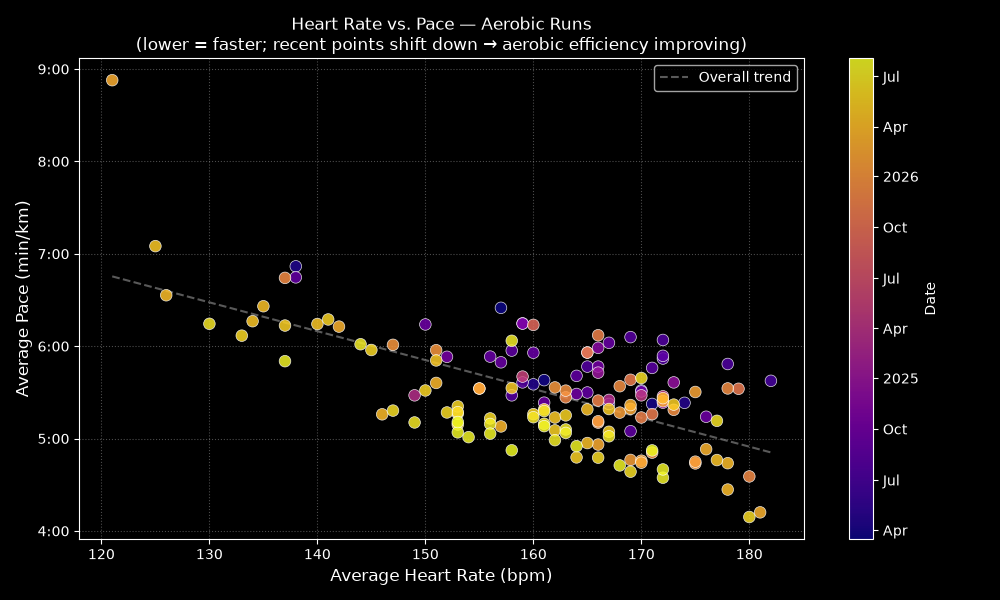

Runs plotted: 150


In [61]:
%matplotlib widget
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

FIGURES_DIR = r"C:\Users\persif\PycharmProjects\SportAnalytics\figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Include generic easy runs (Morning/Afternoon/Base/Evening/Lunch Run etc.)
# Exclude structured workouts by name
EXCLUDE = r"interval|sprint|tempo|fartlek|race|hill repeat|track workout"

easy_runs = (
    df[
        (df["activity_type"] == "Run") &
        (~df["activity_name"].str.contains(EXCLUDE, case=False, na=False)) &
        df["avg_heartrate"].notna() &
        df["avg_speed"].notna()
    ]
    .sort_values("start_date")
    .copy()
)

easy_runs["pace_min_per_km"] = 60.0 / easy_runs["avg_speed"]

dates_num = mdates.date2num(easy_runs["start_date"].dt.to_pydatetime())

fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    easy_runs["avg_heartrate"],
    easy_runs["pace_min_per_km"],
    c=dates_num,
    cmap="plasma",
    s=70,
    alpha=0.85,
    edgecolors="white",
    linewidths=0.5,
    zorder=3,
)

if len(easy_runs) >= 2:
    z = np.polyfit(easy_runs["avg_heartrate"], easy_runs["pace_min_per_km"], 1)
    p = np.poly1d(z)
    hr_range = np.linspace(easy_runs["avg_heartrate"].min(), easy_runs["avg_heartrate"].max(), 200)
    ax.plot(hr_range, p(hr_range), "--", color="gray", linewidth=1.5, alpha=0.7, label="Overall trend")
    ax.legend(fontsize=10)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Date", fontsize=10)
loc = mdates.AutoDateLocator()
cbar.ax.yaxis.set_major_locator(loc)
cbar.ax.yaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))

def pace_formatter(x, _):
    mins = int(x)
    secs = int(round((x - mins) * 60))
    return f"{mins}:{secs:02d}"

ax.yaxis.set_major_formatter(plt.FuncFormatter(pace_formatter))
ax.set_xlabel("Average Heart Rate (bpm)", fontsize=12)
ax.set_ylabel("Average Pace (min/km)", fontsize=12)
ax.set_title("Heart Rate vs. Pace — Aerobic Runs\n(lower = faster; recent points shift down → aerobic efficiency improving)", fontsize=12)
ax.grid(alpha=0.3, linestyle=":")

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "2-5_hr_vs_pace_aerobic_runs.png"), dpi=150)
plt.show()

print(f"Runs plotted: {len(easy_runs)}")